In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scienceplots

%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("pdf", "svg")

DATA_DIR = Path("results")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# layout defaults
SINGLE_COL_WIDTH = 3.5
DOUBLE_COL_WIDTH = 7.16
DPI = 150

# fixed z-order levels
Z_PATCH = -1
Z_BG    = 0
Z_REF   = 2
Z_DATA  = 3

# global plot styling
plt.style.use(["science", "ieee"])
plt.rcParams.update({"mathtext.fontset": "cm", "text.usetex": False})

# hardcoded seaborn-colorblind palette
SB_COLORBLIND = [
    "#0173b2", "#de8f05", "#029e73", "#d55e00", "#cc78bc",
    "#ca9161", "#fbafe4", "#949494", "#ece133", "#56b4e9",
]

# shared styles
STYLE_SUPP = {
    "linestyle": (0, (1.5, 2.8)),
    "linewidth": 0.75,
    "color": "0.20",
    "alpha": 0.30,
}

STYLE_BASELINE = {
    **STYLE_SUPP,
    "alpha": 0.7,
    "linewidth": 0.9,
    "color": "0.35",
}

In [3]:
OVERLAP_SIZES = [10, 20]
N_SEEDS_USED = 10

dfs = []

for V in OVERLAP_SIZES:
    files = sorted(DATA_DIR.glob(f"overlap_{V}_seed*.csv"))[:N_SEEDS_USED]

    if len(files) == 0:
        raise FileNotFoundError(f"No files found for overlap_{V}_seed*.csv")

    print(f"V={V}: using {len(files)} files")
    for f in files:
        print(" ", f.name)

        df = pd.read_csv(f, parse_dates=["timestamp"])
        df["V"] = V
        dfs.append(df)

raw_df = pd.concat(dfs, ignore_index=True)

agg_df = (
    raw_df
    .groupby(["V", "samples"], as_index=False)
    .agg(
        overlap=("overlap", "mean"),
        overlap_std=("overlap", lambda x: x.std(ddof=1)),
        n=("overlap", "count"),
    )
    .sort_values(["V", "samples"])
)

agg_df["overlap_err"] = agg_df["overlap_std"] / np.sqrt(agg_df["n"])

agg_df.head()

V=10: using 10 files
  overlap_10_seed1111.csv
  overlap_10_seed1234.csv
  overlap_10_seed1337.csv
  overlap_10_seed2024.csv
  overlap_10_seed2222.csv
  overlap_10_seed2718.csv
  overlap_10_seed3333.csv
  overlap_10_seed4444.csv
  overlap_10_seed5555.csv
  overlap_10_seed8080.csv
V=20: using 10 files
  overlap_20_seed1111.csv
  overlap_20_seed1234.csv
  overlap_20_seed1337.csv
  overlap_20_seed2024.csv
  overlap_20_seed2222.csv
  overlap_20_seed2718.csv
  overlap_20_seed3333.csv
  overlap_20_seed4444.csv
  overlap_20_seed5555.csv
  overlap_20_seed8080.csv


,V,samples,overlap,overlap_std,n,overlap_err
0,10,50,0.604576,0.004032,10,0.001275
1,10,100,0.612036,0.002861,10,0.000905
2,10,200,0.622975,0.003919,10,0.001239
3,10,500,0.639981,0.004077,10,0.001289
4,10,1000,0.691440,0.007509,10,0.002374


Saved: w_l10_l20_sample_eff_err.svg


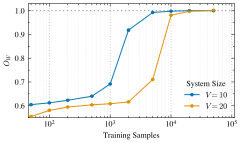

In [4]:
FIG_NAME = "w_l10_l20_sample_eff_err.svg"

# -----------------
# local settings
# -----------------
XLIM = (45, 1.1e5)
YLIM = (0.55, 1.03)

COLOR_V10 = SB_COLORBLIND[0]
COLOR_V20 = SB_COLORBLIND[1]

SIZE_MARKER = 3.6
LINEWIDTH = 1.0
LINE_ALPHA = 0.95

ERR_ELINEWIDTH = 0.7
ERR_CAPSIZE = 1.6
ERR_CAPTHICK = 0.9
ERR_ALPHA = 0.85

FIG_MARGINS = {
    "left": 0.16,
    "right": 0.98,
    "bottom": 0.25,
    "top": 0.95,
}

style_map = {
    10: {"color": COLOR_V10, "label": r"$V=10$"},
    20: {"color": COLOR_V20, "label": r"$V=20$"},
}

width = SINGLE_COL_WIDTH
height = width * 0.65

fig, ax = plt.subplots(figsize=(width, height), dpi=DPI)
ax.patch.set_zorder(Z_PATCH)

# dashed baseline at perfect overlap, no legend
ax.axhline(1.0, zorder=Z_REF, **STYLE_BASELINE)

for V in OVERLAP_SIZES:
    sub = agg_df[agg_df["V"] == V].sort_values("samples")
    color = style_map[V]["color"]

    ax.plot(
        sub["samples"],
        sub["overlap"],
        color=color,
        linestyle="-",
        linewidth=LINEWIDTH,
        alpha=LINE_ALPHA,
        marker="o",
        markersize=SIZE_MARKER,
        markerfacecolor=color,
        markeredgecolor=color,
        markeredgewidth=0.0,
        zorder=Z_DATA,
        label=style_map[V]["label"],
    )

    ax.errorbar(
        sub["samples"],
        sub["overlap"],
        yerr=sub["overlap_err"],
        fmt="None",
        ecolor=color,
        elinewidth=ERR_ELINEWIDTH,
        capsize=ERR_CAPSIZE,
        capthick=ERR_CAPTHICK,
        alpha=ERR_ALPHA,
        zorder=Z_DATA + 1,
        label="_nolegend_",
    )

ax.set_xscale("log")
ax.set_xlim(XLIM)
ax.set_ylim(YLIM)

ax.set_xlabel(r"Training Samples")
ax.set_ylabel(r"$O_W$")

ax.xaxis.set_major_locator(mticker.LogLocator(base=10))
ax.xaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
ax.xaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10))

ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

ax.legend(
    loc="lower right",
    frameon=False,
    title=r"System Size",
    handlelength=1.8,
)

# visible vertical grid lines, still thesis-style
ax.grid(True, axis="x", which="major", linestyle=(0, (1.5, 2.8)), linewidth=0.65, alpha=0.42, color="0.25")
ax.grid(True, axis="x", which="minor", linestyle=(0, (1.5, 2.8)), linewidth=0.45, alpha=0.22, color="0.35")

fig.subplots_adjust(**FIG_MARGINS)
fig.set_size_inches(width, height, forward=True)

if FIG_NAME:
    fig.savefig(FIG_DIR / FIG_NAME, bbox_inches="tight")
    print(f"Saved: {FIG_NAME}")

plt.show()

In [5]:
PHASE_PATTERN = "w_phase_phases_seed*.csv"

phase_files = sorted(DATA_DIR.glob(PHASE_PATTERN))

if len(phase_files) == 0:
    raise FileNotFoundError(f"No files found for pattern: {PHASE_PATTERN}")

print(f"Found {len(phase_files)} phase files:")
for f in phase_files:
    print(" ", f.name)

dfs = []

for f in phase_files:
    df = pd.read_csv(f, dtype={"bitstring": str})

    seed = int(f.stem.split("seed")[-1])
    df["seed"] = seed

    dfs.append(df)

phase_raw_df = pd.concat(dfs, ignore_index=True)
phase_raw_df = phase_raw_df.sort_values(["seed", "rank"]).reset_index(drop=True)

# Keep leading zeros robustly
num_bits = int(phase_raw_df["bitstring"].str.len().max())
phase_raw_df["bitstring"] = phase_raw_df["bitstring"].str.zfill(num_bits)


def wrap_0_2pi(x):
    return np.mod(x, 2 * np.pi)


def align_seed_phases(df):
    df = df.sort_values("rank").copy()

    target_ref = df["target_phase"].iloc[0]
    model_ref = df["model_phase"].iloc[0]

    df["target_phase_rel"] = wrap_0_2pi(df["target_phase"] - target_ref)
    df["model_phase_rel"] = wrap_0_2pi(df["model_phase"] - model_ref)

    return df


phase_rel_df = (
    phase_raw_df
    .groupby("seed", group_keys=False)
    .apply(align_seed_phases)
)

phase_agg_df = (
    phase_rel_df
    .groupby(["rank", "state_index", "bitstring"], as_index=False)
    .agg(
        target_phase=("target_phase_rel", "mean"),
        model_phase=("model_phase_rel", "mean"),
        model_phase_std=("model_phase_rel", lambda x: x.std(ddof=1)),
        n=("model_phase_rel", "count"),
    )
    .sort_values("rank")
)

phase_agg_df["model_phase_err"] = phase_agg_df["model_phase_std"] / np.sqrt(phase_agg_df["n"])

phase_agg_df.head()

Found 10 phase files:
  w_phase_phases_seed1234.csv
  w_phase_phases_seed1618.csv
  w_phase_phases_seed1732.csv
  w_phase_phases_seed3279.csv
  w_phase_phases_seed4338.csv
  w_phase_phases_seed4444.csv
  w_phase_phases_seed4626.csv
  w_phase_phases_seed5555.csv
  w_phase_phases_seed8979.csv
  w_phase_phases_seed9793.csv


,rank,state_index,bitstring,target_phase,model_phase,model_phase_std,n,model_phase_err
0,1,2,0010,0.000000,0.000000,0.000000,10,0.000000
1,2,4,0100,0.149199,0.095537,0.037337,10,0.011807
2,3,8,1000,3.972668,3.876498,0.038544,10,0.012189
3,4,1,0001,5.147079,5.125004,0.035752,10,0.011306


Saved: w_phase_comparison_point_err.svg


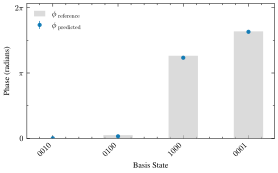

In [6]:
FIG_NAME = "w_phase_comparison_point_err.svg"

plt.style.use(["science", "ieee"])
plt.rcParams.update({"mathtext.fontset": "cm", "text.usetex": False})

# -----------------
# local settings
# -----------------
COLOR_REF  = "0.78"
COLOR_PRED = SB_COLORBLIND[0]

BAR_WIDTH = 0.45
SIZE_PRED = 4.2

ERR_ELINEWIDTH = 0.7
ERR_CAPSIZE    = 2.2
ERR_CAPTHICK   = 0.8
ERR_ALPHA      = 0.90

FIG_MARGINS = {
    "left": 0.13,
    "right": 0.985,
    "bottom": 0.34,
    "top": 0.96,
}

width  = SINGLE_COL_WIDTH * 1.15
height = width * 0.75

plot_df = phase_agg_df.sort_values("rank").copy()
indices = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(width, height), dpi=DPI)
ax.patch.set_zorder(Z_PATCH)

# reference as background bars
ax.bar(
    indices,
    plot_df["target_phase"],
    BAR_WIDTH,
    alpha=0.65,
    color=COLOR_REF,
    label=r"$\phi_{\ \mathrm{reference}}$",
    zorder=Z_DATA,
)

# predicted as points with SEM
ax.errorbar(
    indices,
    plot_df["model_phase"],
    yerr=plot_df["model_phase_err"],
    fmt="o",
    color=COLOR_PRED,
    ecolor=COLOR_PRED,
    markersize=SIZE_PRED,
    markerfacecolor=COLOR_PRED,
    markeredgecolor=COLOR_PRED,
    markeredgewidth=0.0,
    elinewidth=ERR_ELINEWIDTH,
    capsize=ERR_CAPSIZE,
    capthick=ERR_CAPTHICK,
    alpha=ERR_ALPHA,
    zorder=Z_DATA + 2,
    label=r"$\phi_{\ \mathrm{predicted}}$",
)

ax.set_xlabel(r"Basis State")
ax.set_ylabel(r"Phase (radians)")

ax.set_xticks(indices)
ax.set_xticklabels(
    [rf"$\mathrm{{{b}}}$" for b in plot_df["bitstring"]],
    rotation=45,
    ha="right",
)

ax.set_ylim(0, 2 * np.pi + 0.2)

ax.yaxis.set_major_locator(mticker.MultipleLocator(np.pi))
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda y, _: (
            r"$0$" if np.isclose(y, 0)
            else r"$\pi$" if np.isclose(y, np.pi)
            else r"$2\pi$" if np.isclose(y, 2 * np.pi)
            else rf"${y / np.pi:.0f}\pi$"
        )
    )
)

ax.legend(
    loc="upper left",
    frameon=False,
    handlelength=1.4,
)

ax.grid(False)

fig.subplots_adjust(**FIG_MARGINS)
fig.set_size_inches(width, height, forward=True)

if FIG_NAME:
    fig.savefig(FIG_DIR / FIG_NAME, bbox_inches="tight")
    print(f"Saved: {FIG_NAME}")

plt.show()